UTS Data Science


*   Nama : Novika Ardiyaningtyas
*   NIM : 250401020135
*   Kelas: IF401

In [1]:
#Langkah 1: Load & Inspect Dataset
#Muat dataset iris menggunakan seaborn.load_dataset(). Tampilkan shape, dtypes, head(), dan .describe().

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
df = sns.load_dataset('iris')
print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))


Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

Data Iris terdiri dari 150 baris dan lima kolom yang berisi informasi tentang ukuran sepal dan petal dari tiga spesies bunga iris, menurut penyelidikan awal. Untuk kolom species, tipe kategorik (object) digunakan, sedangkan semua atribut pengukuran menggunakan tipe data numerik (float64).

Hasil pemeriksaan menunjukkan bahwa kumpulan data memiliki struktur data yang lengkap dan siap untuk digunakan untuk analisis lebih lanjut. Sebelum melakukan analisis statistik dan visualisasi data, tahap eksplorasi awal ini penting untuk memahami karakteristik dataset sebelum melakukan analisis statistik. Tahap deskriptif memberikan gambaran tentang nilai rata-rata, minimum, dan maksimum setiap variabel.

In [2]:
#Langkah 2: Statistik Deskriptif Lengkap
#Hitung mean, median, std, varians, skewness, kurtosis untuk setiap kolom numerik.

for col_name in df.select_dtypes(include='number').columns:
 col = df[col_name]
 print(f'\n=== {col_name} ===')
 print(f' Mean : {col.mean():.3f}')
 print(f' Median : {col.median():.3f}')
 print(f' Std Dev : {col.std():.3f}')
 print(f' Skewness : {col.skew():.3f}')
 print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


Setiap variabel numerik memiliki atribut unik, menurut perhitungan statistik deskriptif yang dilakukan pada dataset Iris. Sebagian besar data tidak menunjukkan penyimpangan yang signifikan dari pusat distribusi, seperti yang ditunjukkan oleh nilai mean dan median yang hampir sama.

Nilai skewness seluruh variabel hampir nol, yang menunjukkan bahwa distribusi data cenderung simetris atau hanya sedikit kemencengan. Di sisi lain, nilai kurtosis sebagian besar negatif, yang menunjukkan bahwa distribusi data lebih datar dan tidak memiliki puncak yang terlalu tajam.

Sebelum melakukan analisis dan visualisasi lebih lanjut, analisis statistik deskriptif ini membantu dalam mendapatkan pemahaman awal tentang persebaran dan bentuk distribusi data.

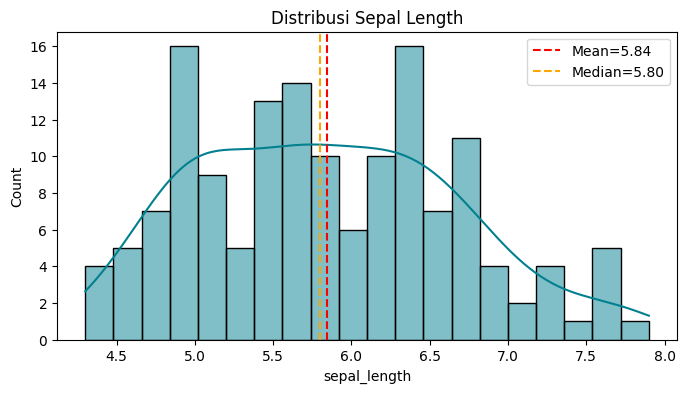

In [3]:
#Langkah 3: Analisis Distribusi (Histogram + KDE)
#Buat histogram + KDE untuk sepal_length. Tambahkan garis mean dan median. Identifikasi jenis distribusinya.

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
 color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
 linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
 linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()

Menurut histogram dan kurva KDE untuk variabel sepal_length, distribusi data tampak cukup merata dan sebanding dengan distribusi normal. Dengan nilai yang sangat dekat, mean (5,84) dan median (5,80) menunjukkan bahwa informasi relatif simetris dan tidak menunjukkan kemencengan yang signifikan.

Sebagian besar data sepal_length berada di antara 5 dan 6,5 cm, dengan frekuensi tertinggi di sekitar nilai distribusi tengah. Tidak ada anomali yang signifikan atau penyimpangan yang terlihat. Hasil ini menunjukkan bahwa variabel sepal_length memiliki pola distribusi yang cukup baik, sehingga dapat digunakan dalam pemodelan dan analisis statistik.

/tmp/ipykernel_638/2589046675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length',
/tmp/ipykernel_638/2589046675.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length',


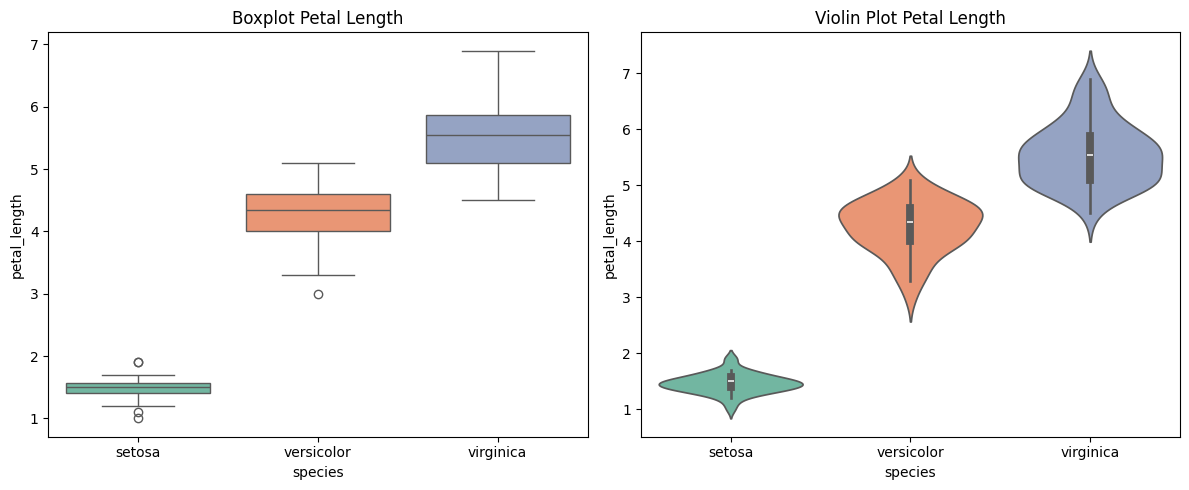

In [4]:
#Langkah 4: Boxplot per Spesies
#Buat boxplot petal_length per spesies. Identifikasi spesies dengan nilai terbesar, terkecil, dan paling tersebar.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length',
 palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length',
 palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout(); plt.show()

Berdasarkan boxplot dan violin plot variabel petal_length, terlihat perbedaan yang jelas antara ketiga spesies bunga Iris. Spesies setosa memiliki nilai petal_length paling kecil dan memiliki rentang data yang paling kecil, yang menunjukkan variasi yang rendah. Spesies versicolor memiliki nilai petal_length paling besar dan memiliki penyebaran data yang sedang di antara setosa dan virginica.

Karena masing-masing spesies Iris memiliki karakteristik ukuran petal yang jelas berbeda, variabel ukuran petal sangat efektif untuk membedakan ketiga spesies Iris. Namun, spesies virginica memiliki nilai petal_length terbesar dan rentang data yang paling lebar, yang menunjukkan variasi data yang lebih besar. Hasil visualisasi ini menunjukkan bahwa variabel petal_length sangat efektif untuk membedakan ketiga spesies Iris.

In [5]:
#Langkah 5: Matriks Korelasi Pearson
#Hitung matriks korelasi. Identifikasi pasangan kolom dengan korelasi tertinggi dan terendah.

corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))
import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


Analisis matriks korelasi Pearson menunjukkan bahwa sebagian besar variabel dalam dataset Iris memiliki hubungan yang cukup kuat satu sama lain. Panjang petal dan lebar petal memiliki korelasi tertinggi, dengan nilai korelasi 0,963, yang menunjukkan korelasi positif yang signifikan. Ini berarti bahwa lebih panjang petal, lebih lebar petal juga cenderung.

Sebaliknya, ada korelasi paling negatif antara lebar sepal dan panjang sepal, dengan nilai korelasi -0,428. Nilai ini menunjukkan bahwa, meskipun korelasi ini tidak terlalu kuat, lebar sepal lebih sering meningkat daripada lebar sepal.

Hasil analisis korelasi menunjukkan bahwa pasangan variabel petal_length dan petal_width adalah yang paling relevan dan mungkin merupakan fitur utama dalam proses klasifikasi spesies bunga Iris.

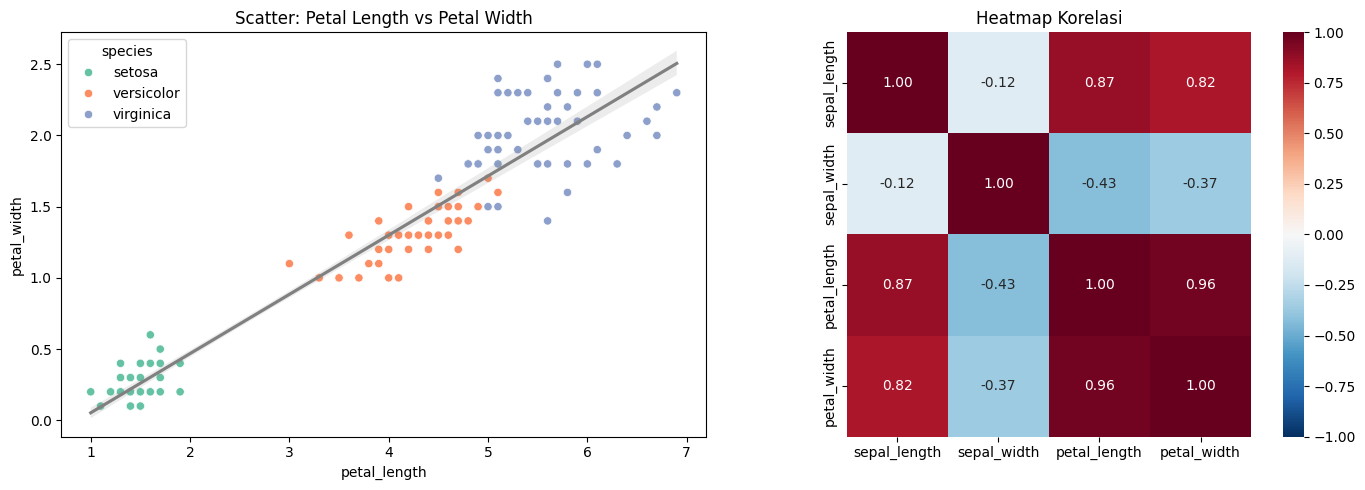

In [6]:
#Langkah 6: Scatter Plot & Heatmap
#Buat scatter plot pasangan paling berkorelasi + heatmap lengkap. Sertakan narasi interpretasi dalam Markdown.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
 hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
 scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
 vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()


petal_length dan petal_width menunjukkan korelasi yang sangat positif berdasarkan scatter plot dan heatmap korelasi. Pola titik yang membentuk garis naik dan nilai korelasi 0,96.  Selain itu, plot dispersi menunjukkan bahwa ketiga spesies Iris memiliki karakteristik yang berbeda dan mungkin berasal dari kelompok yang berbeda. Spesies setosa sangat berbeda dari versicolor dan virginica; namun, versicolor dan virginica dapat dibedakan berdasarkan ukuran petalnya.

Hasil analisis sebelumnya diperkuat oleh korelasi heatmap: variabel petal_length dan petal_width memiliki korelasi tertinggi, sementara sepal_width memiliki korelasi negatif yang relatif lemah terhadap variabel petal. Hasil ini menunjukkan bahwa fitur petal adalah atribut yang paling informatif untuk membedakan spesies bunga Iris. Fitur ini mungkin sangat berguna dalam proses klasifikasi data.

Kesimpulan: Dengan menggunakan statistik deskriptif, distribusi data, boxplot, dan analisis korelasi, analisis dataset Iris memberikan gambaran tentang karakteristik setiap variabel. Distribusi nilai sepal_length menunjukkan pola distribusi normal yang dekat dengan median dan mean. Dengan melihat panjang petal per spesies, terlihat perbedaan yang jelas antara spesies. Iris setosa memiliki ukuran petal paling kecil, sedangkan Iris virginica memiliki ukuran petal terbesar dan variasi data yang lebih besar. Menurut analisis korelasi, ada korelasi positif antara panjang petal dan lebar petal. Untuk memahami pola dan hubungan antar variabel dalam kumpulan data, analisis korelasi, statistik deskriptif, dan visualisasi data digunakan. Hasil analisis menunjukkan bahwa visualisasi dan korelasi adalah alat yang efektif untuk mengeksplorasi dan memahami data sebelum dilakukan analisis lebih lanjut.